# Notebook 2 — OCR Multimedia Pipeline

**Run this notebook from:** `notebooks\`

**Input:** `notebooks\data\processed\phase4_ocr_evidence.csv` (already exists ✅)

**Outputs saved to** `notebooks\data\processed\`:
- `phase4_ocr_cleaned.csv`
- `phase4_meme_analysis.csv` ← used by Notebook 3

---
OCR has already been run on all 8500 memes.
This notebook loads those results, cleans the text, runs toxicity scoring, and saves the final output.

In [1]:
# ── CELL 1 — Imports & Path Check ──────────────────────────────────────────
import re
import pandas as pd
import numpy as np
from pathlib import Path
from transformers import pipeline

# Paths — relative to notebooks\ folder
PROCESSED = Path('data') / 'processed'
OCR_FILE  = PROCESSED / 'phase4_ocr_evidence.csv'

print('✅ Cell 1 OK')
print(f'   PROCESSED     : {PROCESSED.resolve()}')
print(f'   OCR file found: {OCR_FILE.exists()}')

assert OCR_FILE.exists(), (
    f'\n❌ File not found: {OCR_FILE.resolve()}'
    f'\n   Expected: notebooks\\data\\processed\\phase4_ocr_evidence.csv'
)

✅ Cell 1 OK
   PROCESSED     : C:\Users\tejas\Major_Project\AI_Digital_Evidence_Extraction\notebooks\data\processed
   OCR file found: True


In [2]:
# ── CELL 2 — Load Existing OCR Results ────────────────────────────────────
df = pd.read_csv(OCR_FILE)

# Ensure ocr_text column exists and has no nulls
if 'ocr_text' not in df.columns:
    raise ValueError('❌ ocr_text column missing from phase4_ocr_evidence.csv')

df['ocr_text'] = df['ocr_text'].fillna('').astype(str)

non_empty = (df['ocr_text'].str.strip() != '').sum()

print(f'✅ Cell 2 OK — {len(df):,} rows loaded')
print(f'   Columns      : {list(df.columns)}')
print(f'   Non-empty OCR: {non_empty:,} / {len(df):,}')
df[['image_name', 'ocr_text']].head()

✅ Cell 2 OK — 8,500 rows loaded
   Columns      : ['image_name', 'image_path', 'ocr_text']
   Non-empty OCR: 8,289 / 8,500


,image_name,ocr_text
0,meme_0.png,its their character\nLt\nleit\nnot their colo
1,meme_1.png,| contierairard to fove |\nagain -\n\nswam Moa...
2,meme_10.png,jewinad?\n\n~ ‘ey\nget fuhrerious!\nPere
3,meme_100.png,">\nl 7 “?\nNy\n\\n7 4 a ,\nry\n‘ee '\nN\ wee:"
4,meme_1000.png,Ultimateenronsiune\noO aa: . Way\nSag ‘ \)\nno...


In [3]:
# ── CELL 3 — Clean OCR Text & Save ────────────────────────────────────────
def clean_ocr_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)           # remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)   # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()       # collapse spaces
    return text

df['clean_text'] = df['ocr_text'].apply(clean_ocr_text)

out = PROCESSED / 'phase4_ocr_cleaned.csv'
df.to_csv(out, index=False)

print(f'✅ Cell 3 OK — saved to {out.name}')
print(f'   Rows with clean text (>5 chars): '
      f'{(df["clean_text"].str.len() > 5).sum():,}')
df[['image_name', 'ocr_text', 'clean_text']].head()

✅ Cell 3 OK — saved to phase4_ocr_cleaned.csv
   Rows with clean text (>5 chars): 7,938


,image_name,ocr_text,clean_text
0,meme_0.png,its their character\nLt\nleit\nnot their colo,its their character lt leit not their colo
1,meme_1.png,| contierairard to fove |\nagain -\n\nswam Moa...,contierairard to fove again swam moat oo vourex v
2,meme_10.png,jewinad?\n\n~ ‘ey\nget fuhrerious!\nPere,jewinad ey get fuhrerious pere
3,meme_100.png,">\nl 7 “?\nNy\n\\n7 4 a ,\nry\n‘ee '\nN\ wee:",l 7 ny 7 4 a ry ee n wee
4,meme_1000.png,Ultimateenronsiune\noO aa: . Way\nSag ‘ \)\nno...,ultimateenronsiune oo aa way sag nositignidety...


In [4]:
# ── CELL 4 — Load Toxicity Model ──────────────────────────────────────────
#
# unitary/toxic-bert uses safetensors format
# Works on torch 2.5.x without any upgrade needed

toxicity_classifier = pipeline(
    'text-classification',
    model='unitary/toxic-bert',
    truncation=True,
    max_length=512
)

print('✅ Cell 4 OK — toxic-bert loaded')

Device set to use cpu


✅ Cell 4 OK — toxic-bert loaded


In [5]:
# ── CELL 5 — Run Toxicity on Meme Text ────────────────────────────────────
#
# Only rows where OCR extracted meaningful text (>5 chars)
# Short/garbled OCR rows are skipped and get severity_score = 0

has_text = df['clean_text'].str.len() > 5
texts    = df.loc[has_text, 'clean_text'].tolist()
idx_list = df.index[has_text].tolist()

print(f'Running toxicity on {len(texts):,} memes with usable text...')

results = toxicity_classifier(texts, batch_size=32, truncation=True)

df['toxicity_label'] = None
df['toxicity_score'] = None
df.loc[idx_list, 'toxicity_label'] = [r['label'] for r in results]
df.loc[idx_list, 'toxicity_score'] = [round(r['score'], 4) for r in results]

print(f'✅ Cell 5 OK — toxicity scoring done')
print(f'   Rows scored: {df["toxicity_score"].notna().sum():,}')

Running toxicity on 7,938 memes with usable text...
✅ Cell 5 OK — toxicity scoring done
   Rows scored: 7,938


In [6]:
# ── CELL 6 — Severity Scoring & Final Save ────────────────────────────────
#
# toxic-bert labels:  'toxic' or 'neutral'
# Severity scale:  0 = Low | 1 = Moderate | 2 = High | 3 = Critical

def meme_severity(row):
    if pd.isna(row['toxicity_score']):
        return 0
    if str(row['toxicity_label']).lower() != 'toxic':
        return 0
    score = float(row['toxicity_score'])
    if score >= 0.90: return 3  # Critical
    if score >= 0.75: return 2  # High
    if score >= 0.50: return 1  # Moderate
    return 0                    # Low

df['severity_score'] = df.apply(meme_severity, axis=1)

out = PROCESSED / 'phase4_meme_analysis.csv'
df.to_csv(out, index=False)

print(f'✅ Cell 6 OK — saved to {out.name}')
print('\nSeverity breakdown:')
print(
    df['severity_score'].value_counts().sort_index()
    .rename({0: '0 — Low', 1: '1 — Moderate', 2: '2 — High', 3: '3 — Critical'})
)

✅ Cell 6 OK — saved to phase4_meme_analysis.csv

Severity breakdown:
severity_score
0 — Low         5886
1 — Moderate    1218
2 — High         730
3 — Critical     666
Name: count, dtype: int64


In [8]:
# Quick inspection — run this before Cell 7
df_memes = pd.read_csv(PROCESSED / 'df_memes.csv')
print(df_memes.columns.tolist())
print(df_memes.head(3))
print(df_memes['messages'].head(3))

['messages', 'images']
                                            messages  \
0  [{'role': 'user', 'content': '"Given a meme wi...   
1  [{'role': 'user', 'content': '"Given a meme wi...   
2  [{'role': 'user', 'content': '"Given a meme wi...   

                                              images  
0  [{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...  
1  [{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...  
2  [{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...  
0    [{'role': 'user', 'content': '"Given a meme wi...
1    [{'role': 'user', 'content': '"Given a meme wi...
2    [{'role': 'user', 'content': '"Given a meme wi...
Name: messages, dtype: object


    OCR PIPELINE SUMMARY STATISTICS
  Total memes processed  : 8,500
  Memes with OCR text    : 7,938 (93.4%)
  Memes without text     : 562 (6.6%)
  Harmful memes detected : 2,614 (30.8%)
  Non-harmful memes      : 5,886 (69.2%)
  Unscored (no text)     : 562

Severity Breakdown:
  0 — Low       : 5,886 (69.2%)
  1 — Moderate  : 1,218 (14.3%)
  2 — High      : 730 (8.6%)
  3 — Critical  : 666 (7.8%)


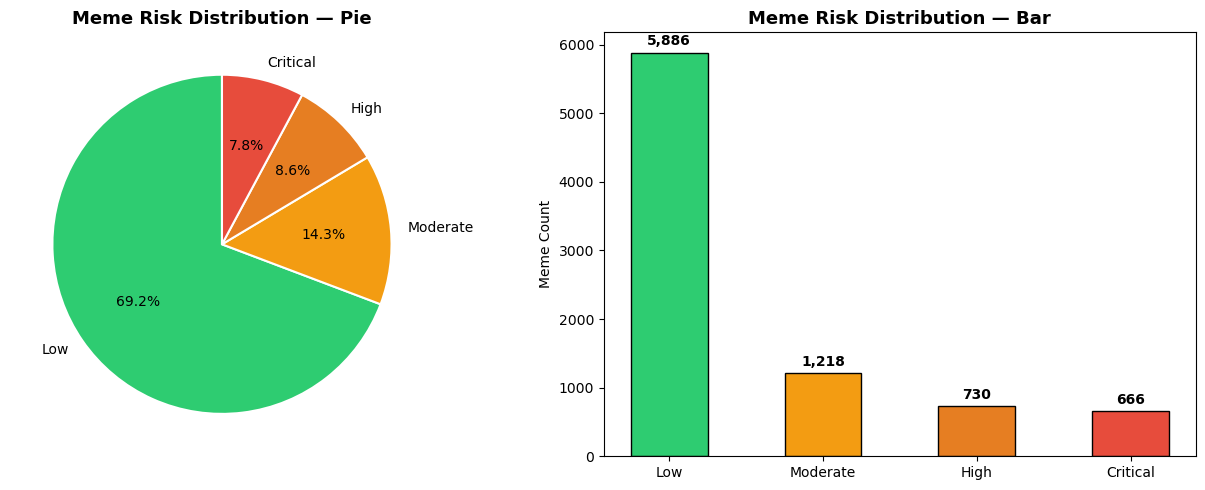


✅ Cell 7 OK


In [11]:
# ── CELL 7 — OCR Pipeline Analysis & Statistics ───────────────────────────
import matplotlib.pyplot as plt

total      = len(df)
has_text   = (df['clean_text'].str.len() > 5).sum()
no_text    = total - has_text
unscored   = df['toxicity_score'].isna().sum()

# Use score threshold to determine actually toxic vs not
# score >= 0.5 and label == toxic → actually harmful
actually_toxic   = (
    (df['toxicity_label'] == 'toxic') &
    (df['toxicity_score'] >= 0.50)
).sum()
not_toxic = total - actually_toxic

print('=' * 45)
print('    OCR PIPELINE SUMMARY STATISTICS')
print('=' * 45)
print(f'  Total memes processed  : {total:,}')
print(f'  Memes with OCR text    : {has_text:,} ({has_text/total*100:.1f}%)')
print(f'  Memes without text     : {no_text:,} ({no_text/total*100:.1f}%)')
print(f'  Harmful memes detected : {actually_toxic:,} ({actually_toxic/total*100:.1f}%)')
print(f'  Non-harmful memes      : {not_toxic:,} ({not_toxic/total*100:.1f}%)')
print(f'  Unscored (no text)     : {unscored:,}')
print('=' * 45)

print('\nSeverity Breakdown:')
severity_counts = df['severity_score'].value_counts().sort_index()
for k, v in severity_counts.items():
    label = {0:'Low', 1:'Moderate', 2:'High', 3:'Critical'}[k]
    print(f'  {k} — {label:<10}: {v:,} ({v/total*100:.1f}%)')

# Chart
labels = ['Low', 'Moderate', 'High', 'Critical']
values = [int(severity_counts.get(i, 0)) for i in range(4)]
clr    = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(values, labels=labels, autopct='%1.1f%%',
            colors=clr, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Meme Risk Distribution — Pie',
                  fontsize=13, fontweight='bold')

bars = axes[1].bar(labels, values, color=clr, edgecolor='black', width=0.5)
axes[1].set_title('Meme Risk Distribution — Bar',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Meme Count')
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f'{val:,}', ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.savefig(PROCESSED / 'meme_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Cell 7 OK')

In [10]:
# Quick check — what labels is toxic-bert actually returning for memes?
print(df['toxicity_label'].value_counts())
print('\nSample rows:')
print(df[['clean_text', 'toxicity_label', 'toxicity_score']].dropna().head(10))

toxicity_label
toxic    7938
Name: count, dtype: int64

Sample rows:
                                          clean_text toxicity_label  \
0         its their character lt leit not their colo          toxic   
1  contierairard to fove again swam moat oo vourex v          toxic   
2                     jewinad ey get fuhrerious pere          toxic   
3                           l 7 ny 7 4 a ry ee n wee          toxic   
4  ultimateenronsiune oo aa way sag nositignidety...          toxic   
5    eng on teast 7 od et ete bh 4 os a ang cste ies          toxic   
6  my liberal privilege liberal privilege 1 h pro...          toxic   
7                        se jod ee fie belial s a mm          toxic   
8        ag ol look c he already has an arrstwarrant          toxic   
9  assau imnysonexnloned hettr than pap iurstiol ...          toxic   

  toxicity_score  
0         0.0036  
1         0.0365  
2          0.902  
3         0.1253  
4         0.7707  
5         0.0858  
6         0.0142